# R4 - Evaluación del segmentador baseline U-Net

Este notebook evalúa el mejor checkpoint del U-Net baseline en las particiones estandarizadas del proyecto.

La evaluación se realiza en dos niveles:

1. **Validation:** análisis del checkpoint seleccionado durante el desarrollo.
2. **Test:** evaluación final independiente del segmentador baseline.

## 1. Configuración del entorno

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

PROJECT_ROOT = Path("../..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

PROJECT_ROOT: /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification
Device: cuda
GPU: NVIDIA GeForce RTX 3080


## 2. Rutas y recuperación del experimento

In [2]:
DATASET_DIR = (
    PROJECT_ROOT /
    "data" /
    "processed" /
    "MMOTU_OTU_2D_experimental"
)

SPLIT_PATH = (
    PROJECT_ROOT /
    "configs" /
    "splits" /
    "mmotu_experimental_split_standard.csv"
)

MODEL_PATH = (
    PROJECT_ROOT /
    "models" /
    "segmentation" /
    "unet_baseline_best.pth"
)

RESULT_DIR = (
    PROJECT_ROOT /
    "results" /
    "segmentation" /
    "unet_baseline"
)

HISTORY_PATH = RESULT_DIR / "training_history.csv"
FIGURES_DIR = RESULT_DIR / "figures"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Checkpoint:", MODEL_PATH.exists(), MODEL_PATH)
print("Historial:", HISTORY_PATH.exists(), HISTORY_PATH)
print("Dataset:", DATASET_DIR.exists(), DATASET_DIR)

Checkpoint: True /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/models/segmentation/unet_baseline_best.pth
Historial: True /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/results/segmentation/unet_baseline/training_history.csv
Dataset: True /home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/data/processed/MMOTU_OTU_2D_experimental


## 3. Carga del checkpoint y reconstrucción del modelo

In [3]:
from src.segmentation.unet import UNet
from src.segmentation.dataset import OvarianTumorSegmentationDataset

checkpoint = torch.load(
    MODEL_PATH,
    map_location=device,
)

print("Época guardada:", checkpoint["epoch"])
print("Validation Dice:", checkpoint["val_dice"])
print("Validation IoU:", checkpoint["val_iou"])
print("Validation Loss:", checkpoint["val_loss"])

print("\nConfiguración:")
print("Seed:", checkpoint["seed"])
print("Image size:", checkpoint["image_size"])
print("Batch size:", checkpoint["batch_size"])
print("Learning rate:", checkpoint["learning_rate"])

model = UNet(
    in_channels=3,
    out_channels=1,
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("\nModelo cargado correctamente.")

/tmp/ipykernel_276280/946701221.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Época guardada: 45
Validation Dice: 0.714591618180275
Validation IoU: 0.618963115811348
Validation Loss: 0.32439268577843905

Configuración:
Seed: 42
Image size: (256, 256)
Batch size: 4
Learning rate: 0.0001

Modelo cargado correctamente.


## 4. Historial y curvas de aprendizaje

In [4]:
history_df = pd.read_csv(HISTORY_PATH)

best_epoch = int(checkpoint["epoch"])
best_val_dice = float(checkpoint["val_dice"])

best_row = history_df.loc[
    history_df["epoch"] == best_epoch
].iloc[0]

print("Número de épocas registradas:", len(history_df))
print("Mejor época:", best_epoch)

display(history_df.head())
display(history_df.tail())

Número de épocas registradas: 50
Mejor época: 45


,epoch,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,epoch_seconds
0,1,0.439428,2.434527e-11,2.434527e-11,0.402718,2.532758e-11,2.532758e-11,19.088896
1,2,0.328040,6.811632e-02,5.169395e-02,0.287129,4.399397e-01,3.301604e-01,18.953399
2,3,0.261390,4.161498e-01,3.128690e-01,0.290582,5.349583e-01,4.016355e-01,18.994131
3,4,0.249003,4.850938e-01,3.707424e-01,0.226943,5.538983e-01,4.313694e-01,19.048369
4,5,0.230994,5.232983e-01,4.067309e-01,0.246428,4.921530e-01,3.796052e-01,19.047866


,epoch,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,epoch_seconds
45,46,0.019352,0.955121,0.919337,0.244957,0.713299,0.613595,19.070472
46,47,0.020933,0.950204,0.913750,0.297799,0.714076,0.616855,19.091064
47,48,0.019550,0.954622,0.920095,0.297973,0.713798,0.615851,19.087279
48,49,0.018260,0.958740,0.925444,0.313902,0.704292,0.605984,19.077930
49,50,0.018052,0.958701,0.925722,0.295955,0.700202,0.604070,19.053086


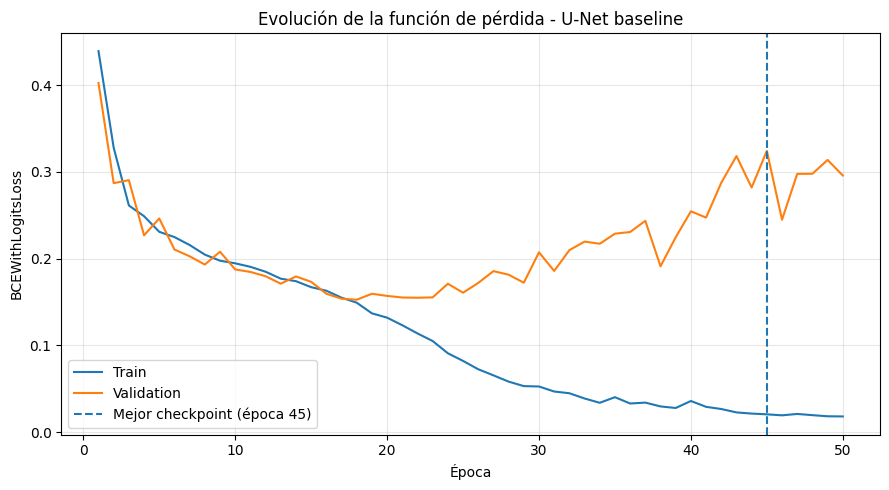

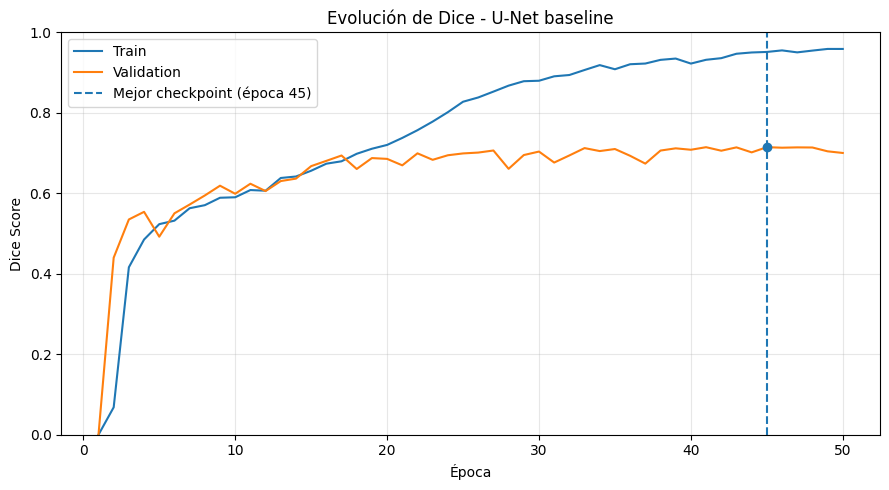

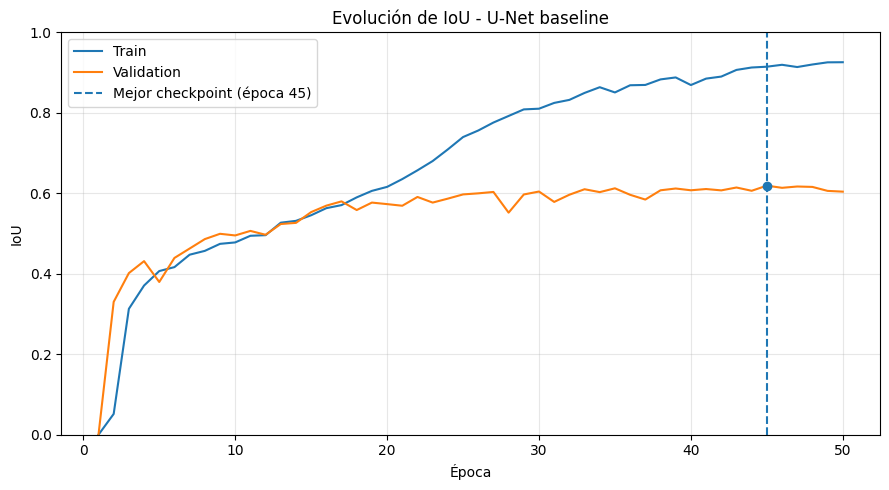

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation")
plt.axvline(best_epoch, linestyle="--", label=f"Mejor checkpoint (época {best_epoch})")
plt.xlabel("Época")
plt.ylabel("BCEWithLogitsLoss")
plt.title("Evolución de la función de pérdida - U-Net baseline")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "unet_baseline_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_dice"], label="Train")
plt.plot(history_df["epoch"], history_df["val_dice"], label="Validation")
plt.axvline(best_epoch, linestyle="--", label=f"Mejor checkpoint (época {best_epoch})")
plt.scatter([best_epoch], [best_val_dice], zorder=5)
plt.xlabel("Época")
plt.ylabel("Dice Score")
plt.title("Evolución de Dice - U-Net baseline")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "unet_baseline_dice_curve.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(history_df["epoch"], history_df["train_iou"], label="Train")
plt.plot(history_df["epoch"], history_df["val_iou"], label="Validation")
plt.axvline(best_epoch, linestyle="--", label=f"Mejor checkpoint (época {best_epoch})")
plt.scatter([best_epoch], [best_row["val_iou"]], zorder=5)
plt.xlabel("Época")
plt.ylabel("IoU")
plt.title("Evolución de IoU - U-Net baseline")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "unet_baseline_iou_curve.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Funciones de evaluación por imagen

In [6]:
def evaluate_per_image(
    model,
    loader,
    device,
    threshold=0.5,
    eps=1e-7,
):
    model.eval()
    records = []

    with torch.no_grad():
        for batch in loader:
            images = batch["image"].to(device, non_blocking=True)
            masks = batch["mask"].to(device, non_blocking=True)
            image_ids = batch["image_id"]

            logits = model(images)
            probabilities = torch.sigmoid(logits)
            predictions = (probabilities >= threshold).float()

            pixel_loss = F.binary_cross_entropy_with_logits(
                logits,
                masks,
                reduction="none",
            )
            image_loss = pixel_loss.mean(dim=(1, 2, 3))

            dimensions = (1, 2, 3)
            intersection = (predictions * masks).sum(dim=dimensions)
            pred_area = predictions.sum(dim=dimensions)
            target_area = masks.sum(dim=dimensions)

            dice = (2.0 * intersection + eps) / (
                pred_area + target_area + eps
            )
            union = pred_area + target_area - intersection
            iou = (intersection + eps) / (union + eps)

            for i, image_id in enumerate(image_ids):
                records.append(
                    {
                        "image_id": str(image_id),
                        "loss": image_loss[i].item(),
                        "dice": dice[i].item(),
                        "iou": iou[i].item(),
                        "real_lesion_fraction": masks[i].mean().item(),
                        "predicted_lesion_fraction": predictions[i].mean().item(),
                    }
                )

    return pd.DataFrame(records)


def summarize_segmentation_results(results_df):
    return pd.DataFrame(
        {
            "metrica": ["Loss", "Dice", "IoU"],
            "promedio": [
                results_df["loss"].mean(),
                results_df["dice"].mean(),
                results_df["iou"].mean(),
            ],
            "mediana": [
                results_df["loss"].median(),
                results_df["dice"].median(),
                results_df["iou"].median(),
            ],
            "desviacion_estandar": [
                results_df["loss"].std(),
                results_df["dice"].std(),
                results_df["iou"].std(),
            ],
            "minimo": [
                results_df["loss"].min(),
                results_df["dice"].min(),
                results_df["iou"].min(),
            ],
            "maximo": [
                results_df["loss"].max(),
                results_df["dice"].max(),
                results_df["iou"].max(),
            ],
        }
    )

## 6. Evaluación sobre validation

In [7]:
IMAGE_SIZE = tuple(checkpoint["image_size"])
BATCH_SIZE = int(checkpoint["batch_size"])
THRESHOLD = float(checkpoint.get("threshold", 0.5))

val_dataset = OvarianTumorSegmentationDataset(
    images_dir=DATASET_DIR / "validation" / "images",
    masks_dir=DATASET_DIR / "validation" / "masks",
    image_size=IMAGE_SIZE,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

print("Validation:", len(val_dataset), "imágenes")

Validation: 200 imágenes


In [8]:
val_results_df = evaluate_per_image(
    model=model,
    loader=val_loader,
    device=device,
    threshold=THRESHOLD,
)

val_summary = summarize_segmentation_results(val_results_df)

display(val_summary)

VAL_DIR = RESULT_DIR / "validation"
VAL_DIR.mkdir(parents=True, exist_ok=True)

val_results_df.to_csv(
    VAL_DIR / "validation_per_image_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
val_summary.to_csv(
    VAL_DIR / "validation_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,metrica,promedio,mediana,desviacion_estandar,minimo,maximo
0,Loss,0.324393,0.127010,0.526120,7.605991e-03,3.307192
1,Dice,0.714592,0.818755,0.279766,5.380104e-12,0.984532
2,IoU,0.618963,0.693144,0.296295,5.380104e-12,0.969535


## 7. Casos representativos en validation

In [9]:
sorted_results = val_results_df.sort_values("dice").reset_index(drop=True)

worst_case = sorted_results.iloc[0]
median_case = sorted_results.iloc[len(sorted_results) // 2]
best_case = sorted_results.iloc[-1]

representative_cases = pd.DataFrame(
    [
        {"case": "worst", **worst_case.to_dict()},
        {"case": "median", **median_case.to_dict()},
        {"case": "best", **best_case.to_dict()},
    ]
)

display(representative_cases)

representative_cases.to_csv(
    VAL_DIR / "representative_cases.csv",
    index=False,
    encoding="utf-8-sig",
)

,case,image_id,loss,dice,iou,real_lesion_fraction,predicted_lesion_fraction
0,worst,775,2.796655,5.380104e-12,5.380104e-12,0.283463,0.000153
1,median,349,0.056622,8.222507e-01,6.981542e-01,0.050873,0.044586
2,best,239,0.028172,9.845318e-01,9.695348e-01,0.416595,0.419922


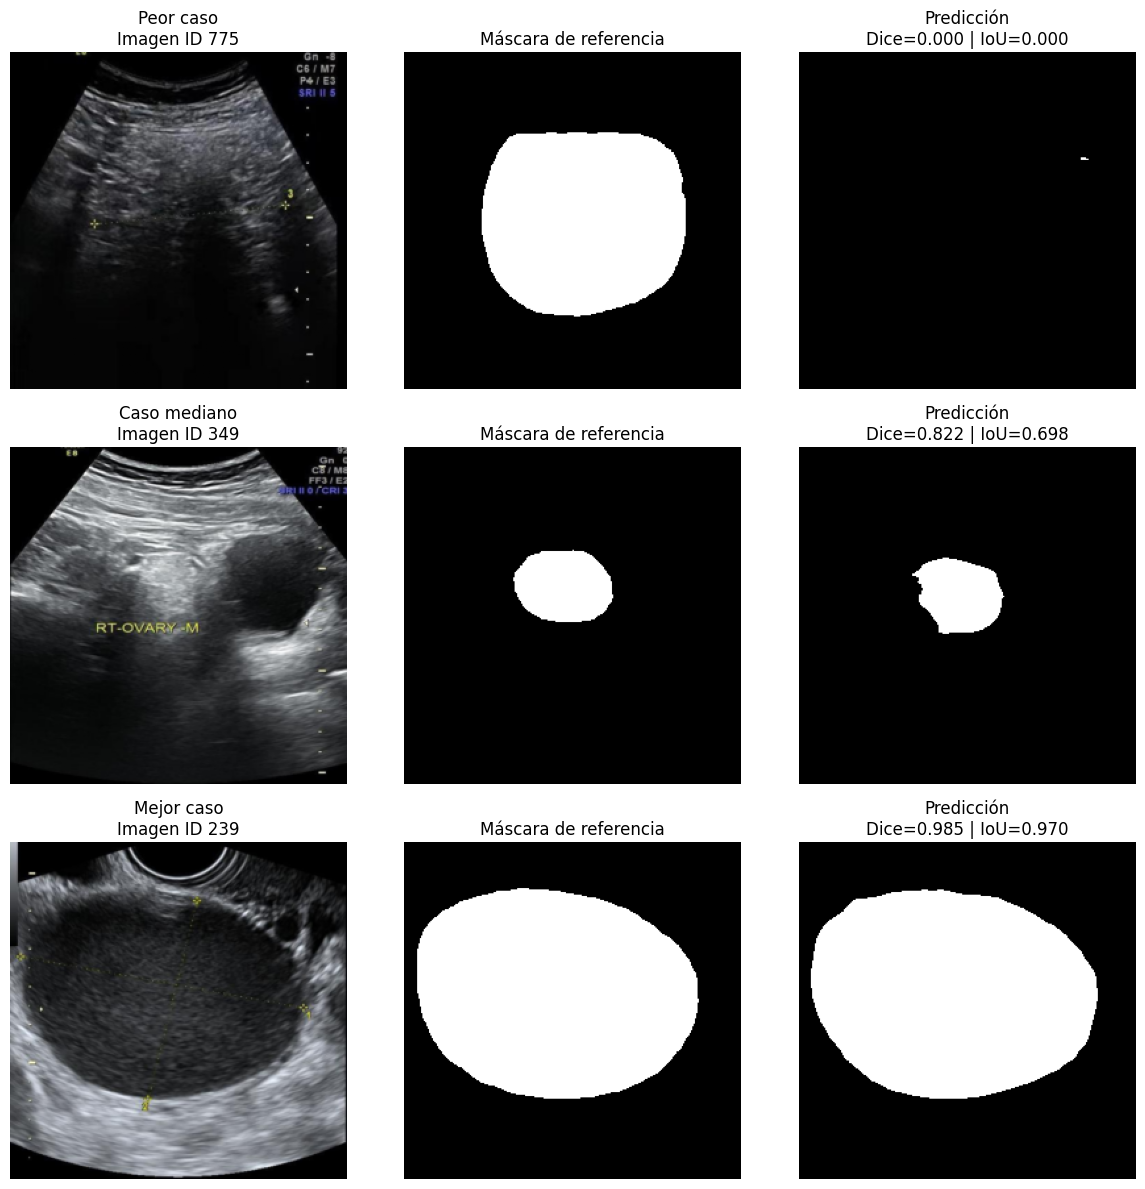

In [10]:
def get_sample_by_id(dataset, image_id):
    image_id = str(image_id)

    for index in range(len(dataset)):
        sample = dataset[index]
        if str(sample["image_id"]) == image_id:
            return sample

    raise ValueError(f"No se encontró image_id={image_id}")


def predict_sample(model, sample, device, threshold=0.5):
    image = sample["image"].unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():
        logits = model(image)
        probability = torch.sigmoid(logits)
        prediction = (probability >= threshold).float()

    return {
        "image": sample["image"].cpu(),
        "mask": sample["mask"].cpu(),
        "probability": probability.squeeze(0).cpu(),
        "prediction": prediction.squeeze(0).cpu(),
    }


case_ids = {
    "Peor caso": str(worst_case["image_id"]),
    "Caso mediano": str(median_case["image_id"]),
    "Mejor caso": str(best_case["image_id"]),
}

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))

for row, (case_name, image_id) in enumerate(case_ids.items()):
    sample = get_sample_by_id(val_dataset, image_id)
    result = predict_sample(model, sample, device, THRESHOLD)

    image = result["image"].permute(1, 2, 0).numpy()
    mask = result["mask"].squeeze(0).numpy()
    prediction = result["prediction"].squeeze(0).numpy()

    row_metrics = val_results_df[
        val_results_df["image_id"] == str(image_id)
    ].iloc[0]

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(f"{case_name}\nImagen ID {image_id}")

    axes[row, 1].imshow(mask, cmap="gray")
    axes[row, 1].set_title("Máscara de referencia")

    axes[row, 2].imshow(prediction, cmap="gray")
    axes[row, 2].set_title(
        f"Predicción\nDice={row_metrics['dice']:.3f} | "
        f"IoU={row_metrics['iou']:.3f}"
    )

    for col in range(3):
        axes[row, col].axis("off")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "representative_segmentations_validation.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 8. Evaluación final sobre test

In [11]:
test_dataset = OvarianTumorSegmentationDataset(
    images_dir=DATASET_DIR / "test" / "images",
    masks_dir=DATASET_DIR / "test" / "masks",
    image_size=IMAGE_SIZE,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
)

print("Test:", len(test_dataset), "imágenes")

Test: 469 imágenes


In [12]:
test_results_df = evaluate_per_image(
    model=model,
    loader=test_loader,
    device=device,
    threshold=THRESHOLD,
)

test_summary = summarize_segmentation_results(test_results_df)

display(test_summary)

print("TEST")
print("=" * 45)
print(f"Dice promedio: {test_results_df['dice'].mean():.6f}")
print(f"Dice mediana:  {test_results_df['dice'].median():.6f}")
print(f"IoU promedio:  {test_results_df['iou'].mean():.6f}")
print(f"Loss promedio: {test_results_df['loss'].mean():.6f}")
print(f"Desviación estándar Dice: {test_results_df['dice'].std():.6f}")

TEST_DIR = RESULT_DIR / "test"
TEST_DIR.mkdir(parents=True, exist_ok=True)

test_results_df.to_csv(
    TEST_DIR / "test_per_image_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)
test_summary.to_csv(
    TEST_DIR / "test_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,metrica,promedio,mediana,desviacion_estandar,minimo,maximo
0,Loss,0.364155,0.167661,0.501082,9.794923e-03,3.725339
1,Dice,0.693463,0.810834,0.297756,1.019264e-11,0.987358
2,IoU,0.599403,0.681850,0.306707,1.019264e-11,0.975032


TEST
Dice promedio: 0.693463
Dice mediana:  0.810834
IoU promedio:  0.599403
Loss promedio: 0.364155
Desviación estándar Dice: 0.297756


## 9. Comparación validation vs test

In [13]:
comparison_df = pd.DataFrame(
    [
        {
            "subset": "validation",
            "n": len(val_results_df),
            "dice_mean": val_results_df["dice"].mean(),
            "dice_median": val_results_df["dice"].median(),
            "iou_mean": val_results_df["iou"].mean(),
            "loss_mean": val_results_df["loss"].mean(),
        },
        {
            "subset": "test",
            "n": len(test_results_df),
            "dice_mean": test_results_df["dice"].mean(),
            "dice_median": test_results_df["dice"].median(),
            "iou_mean": test_results_df["iou"].mean(),
            "loss_mean": test_results_df["loss"].mean(),
        },
    ]
)

display(comparison_df)

comparison_df.to_csv(
    RESULT_DIR / "validation_vs_test_summary.csv",
    index=False,
    encoding="utf-8-sig",
)

,subset,n,dice_mean,dice_median,iou_mean,loss_mean
0,validation,200,0.714592,0.818755,0.618963,0.324393
1,test,469,0.693463,0.810834,0.599403,0.364155
